# Iris: разведочный анализ данных (EDA) для мультиклассовой классификации

**Задача:** Классифицировать 3 класса 

**Что в этом ноутбуке:** только разведочный анализ и обоснование решений по
предобработке/инженерии признаков. Код предобработки живёт в
[`src/house_prices_preprocessing.py`](../src/house_prices_preprocessing.py) и
переиспользуется отсюда и из
[`scripts/iris.py`](../scripts/iris.py) — то есть
здесь мы объясняем ровно ту логику, которая реально используется при обучении.

**Что НЕ в этом ноутбуке:** обучение модели и метрики — это в
`scripts/iris.py`. Теория логистической регрессии — в
[`tutorials/logisticregression.ipynb`](../tutorials/logisticregression.ipynb).

# 1: Смотрим на датасет в общем

In [15]:
from sklearn.datasets import load_iris
import pandas as pd
from utils.plotting import (
    plot_numeric_distributions,
    plot_correlation_heatmap,
    plot_class_balance,
    plot_pairplot,
    plot_scatter_by_class,
    plot_boxplots_by_class,
    plot_kde_by_class,
)

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df = pd.DataFrame(df)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


Переменуем название признаков для удобства, посмотрим описание и на количество пропусков

In [16]:

df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
    "target": "target"
})

df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.info()
df.describe()
df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    int64  
 5   species       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
species         0
dtype: int64

Пропусков в датасете нету, все признаки кроме species числовые, таргет состоит из 3 классов, признак species строковый(он поясняет target). Удалим species, так как он дублирует таргет, но интерпритирует для человека. Далее пользуемся для классво названиями из species для удобства

# 2: Распределение классов и гистограммы признаков

<Axes: title={'center': 'Распределение классов'}, ylabel='Количество объектов'>

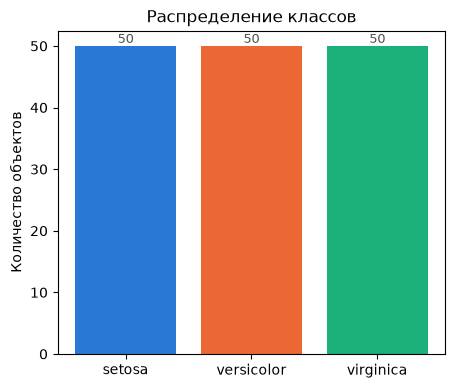

In [17]:
df["species"].value_counts()
plot_class_balance(df["species"])

Все три класса распределены поровну

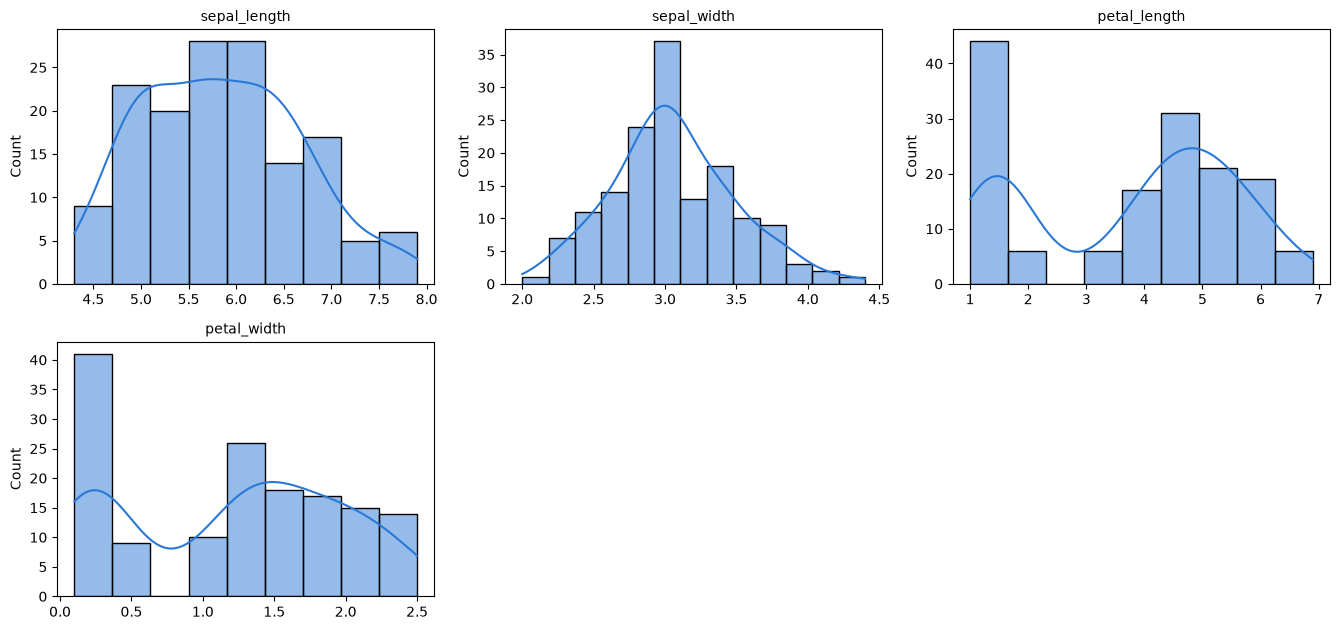

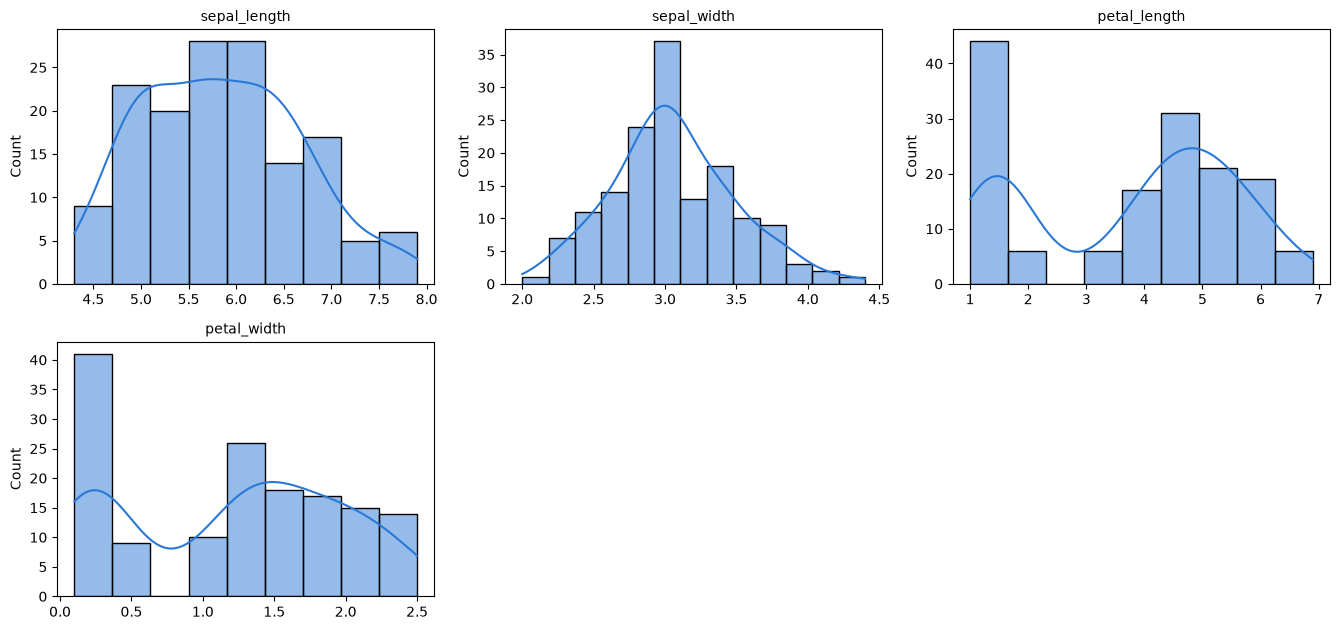

In [18]:
feature_cols = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

plot_numeric_distributions(df, feature_cols)

Стандартизируем данные, т.к. распределения не являются нормальными, хотя и близки(первые 2 признака). Также для логистической регрессии требуется стандартизация.

# 3: Корреляция, взаимное распредление, выбросы

<Axes: title={'center': 'Матрица корреляций'}>

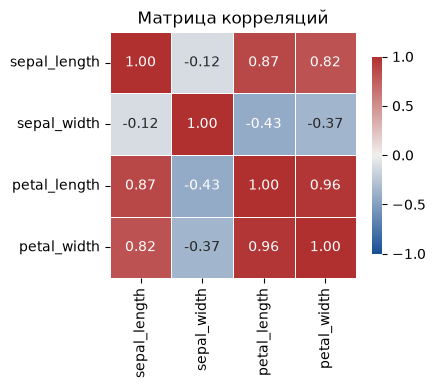

In [7]:
plot_correlation_heatmap(df[feature_cols])

сильная корреляция между petal_width и sepal_length, petal_length и sepal_length, petal_length и petal_width.
Почти все признаки коррелирует друг с другом. Удалять плохо, так как это ведёт к удалению почти всего датасета. Попробую 2 варианта: PCA и регулеризацию для логистической регресии и сравнню, что лучше работает.
```text
Потом я понял, что использовать pca - это большая ошибка, так как все равно размерность теряется, признаков и так мало. Надо применять, когда признаков очень много. Лишняя трата времени и памяти на посик ненужного гиперпараметра
```

/home/andrew/projects/Ml/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/andrew/projects/Ml/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/andrew/projects/Ml/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/andrew/projects/Ml/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/andrew/projects/Ml/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWarning: The palette list has more values (8) than needed (3),

<Axes: title={'center': 'petal_length vs petal_width'}, xlabel='petal_length', ylabel='petal_width'>

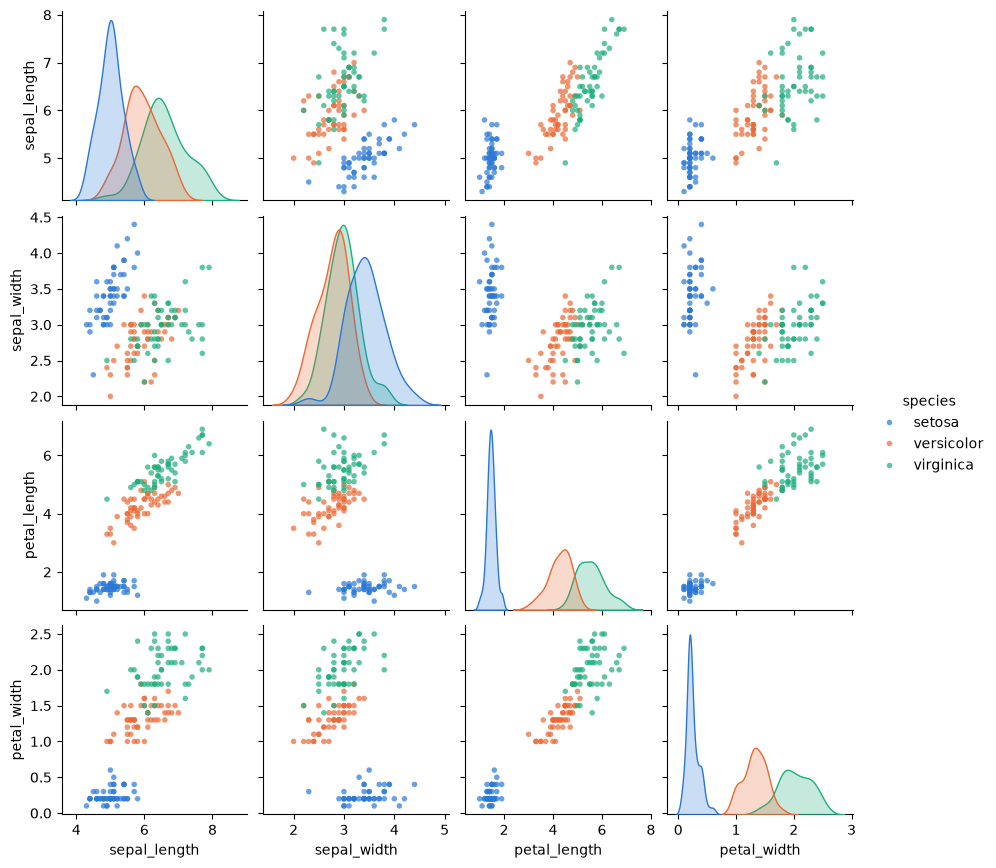

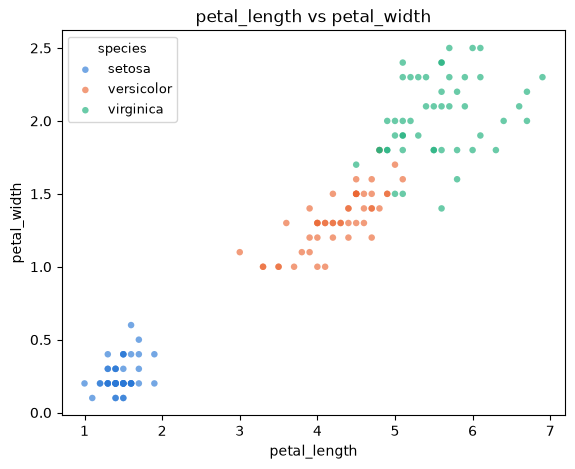

In [8]:
plot_pairplot(df, hue_col="species", cols=feature_cols)
plot_scatter_by_class(df, "petal_length", "petal_width", "species")


setosa лучше всех отделяется от других классов. petal_width и petal_length лучше всего отделяют

/home/andrew/projects/Ml/utils/plotting.py:370: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/andrew/projects/Ml/utils/plotting.py:370: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/andrew/projects/Ml/utils/plotting.py:370: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/andrew/projects/Ml/utils/plotting.py:370: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


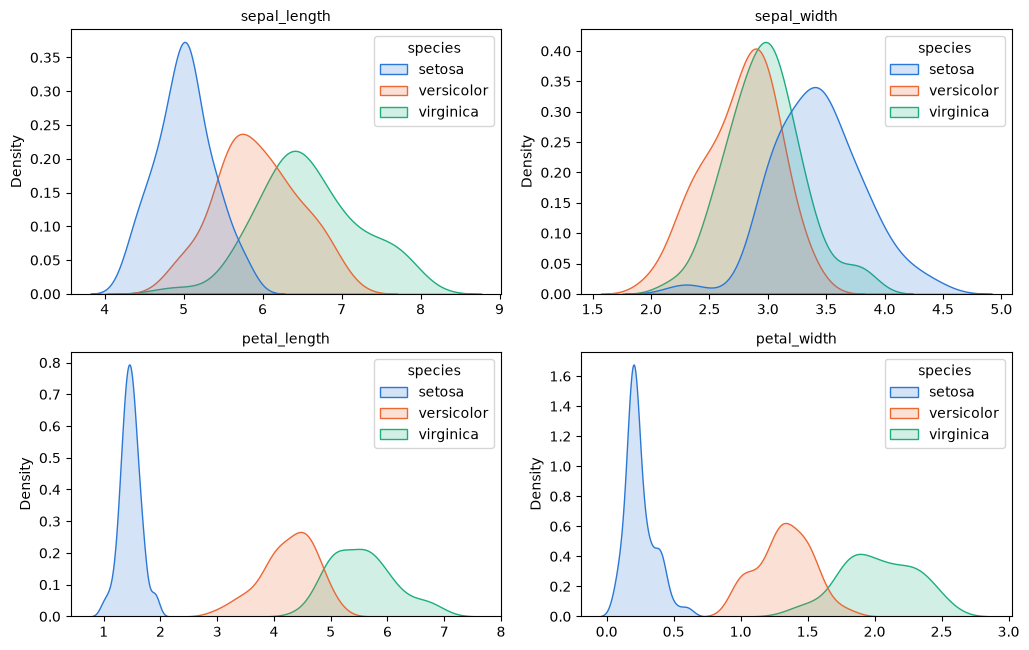

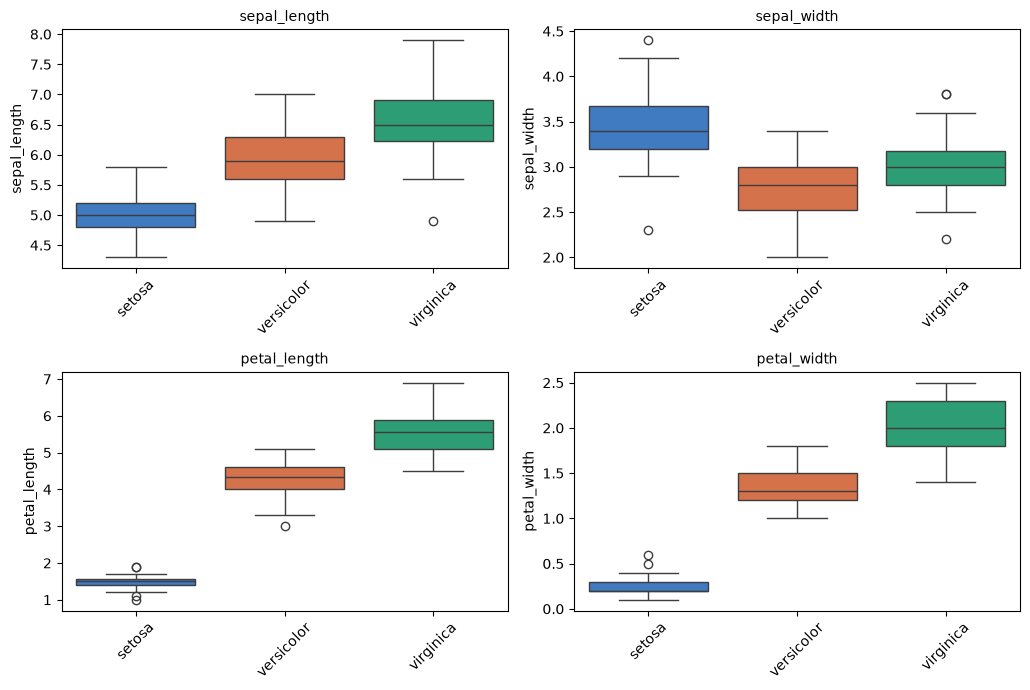

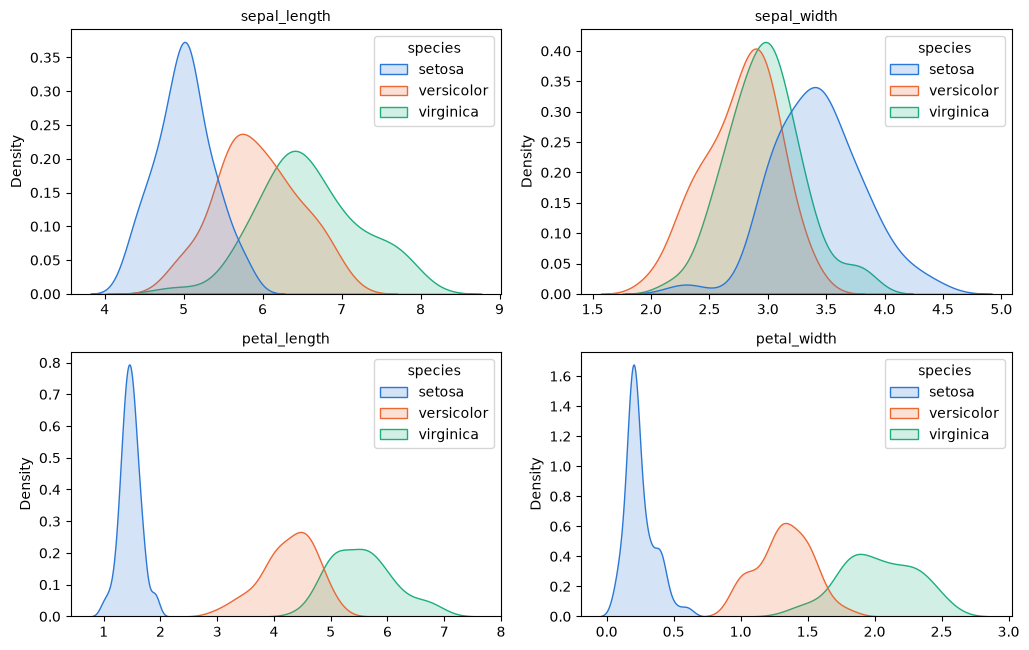

In [9]:
plot_boxplots_by_class(df, "species", feature_cols)
plot_kde_by_class(df, "species", feature_cols)

Выбросов практически нет, лишь единичные случаи и то для своего класса они могут не быть выбрасами. достаточно RobustScaler

# 4: Главные выводы
1. Классы распределены поровну, не надо на тренировочной выборке ставить параметр stratify, можно ориентироваться на метрику accurancy
2. Применяем Rubostscaler для модели логистической регрессии и для PCA. Сравним логистическую регрессию классическую с PCA и логистическую регрессию с ridge регуляризацией. Используем эти методы, так как сильная мультиколлинеарность
3. Выбросов сильных нету, лишь очень редкие случаи. Rubostscaler достаточно
4. Проверим svm для линейно разделимых данных(на карте корреляций видно, что данные линейно зависят друг от друга) и дерево решений для этого датасета.

# 5: Результат по моделям

В `scripts/train_iris.py` проведены обучения моделей с автоподбором гиперпараметров по очищенным данным из `src/iris_preprocessing.py`, рассчеты метрик. Лучшие гиперпараметры для моделей, сами модели, метрики к моделям сохранены в папку `models/iris`, очищенные данные в папку `data/iris/processed`.

Результат сравнения моделей по метрикам:

| Модель | CV Accuracy | Holdout Accuracy | F1 Macro | ROC-AUC OVR | Лучшие гиперпараметры |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Baseline LR | — | 0.9333 | 0.9333 | 0.9883 | *(дефолтные: C=1, без PCA)* |
| Final LR (Ridge) | **0.9667** | 0.9667 | 0.9666 | 1.0000 | `C=10`, `pca=passthrough` |
| SVM Linear | **0.9750** | **1.0000** | **1.0000** | **1.0000** | `C=3`, `pca=passthrough` |
| SVM RBF | **0.9750** | 0.9667 | 0.9666 | 1.0000 | `C=10`, `gamma=0.1`, `pca=passthrough` |
| Decision Tree | 0.9583 | 0.9667 | 0.9666 | 0.9717 | `criterion=gini`, `max_depth=3`, `min_samples_leaf=1`, `min_samples_split=2`, `class_weight=None`, `pca=passthrough` |

---

### Ключевые выводы из таблицы

### 1. Лучшая модель по CV — SVM Linear

По кросс-валидации лучшие результаты у:

```text
SVM Linear:   CV = 0.9750
SVM RBF:      CV = 0.9750
Final LR:     CV = 0.9667
Decision Tree: CV = 0.9583
Baseline LR:  CV ≈ 0.93–0.95 (не измерялось отдельно)
```

То есть **SVM Linear и SVM RBF делят первое место по CV**.

---

### 2. Holdout accuracy = 1.0 у SVM Linear — это удачное совпадение

SVM Linear показал:

```text
CV = 0.9750
Holdout = 1.0000
```

Разница между ними говорит о том, что на конкретном holdout из 30 объектов модель не ошиблась ни разу, но в среднем на других фолдах она ошибается примерно в 2.5% случаев.

Это нормально для Iris, но не стоит воспринимать `1.0000` как гарантию идеальной работы.

---

### 3. Decision Tree слабее всех по CV

```text
Decision Tree CV = 0.9583
```

Это худший результат среди всех настроенных моделей.

При этом на holdout он показал `0.9667`, то есть почти столько же, сколько Final LR. Это ещё раз подтверждает, что на маленьком holdout разница в 1 объект создаёт иллюзию одинакового качества.

---

### 4. PCA нигде не выбрался

Все лучшие параметры содержат:

```python
"pca": "passthrough"
```

Это значит, что для всех пяти моделей вариант без PCA оказался лучше на кросс-валидации.

Для Iris с 4 признаками это ожидаемый результат.

---

### 5. Baseline vs Final LR

```text
Baseline LR holdout = 0.9333
Final LR holdout    = 0.9667
Final LR CV         = 0.9667
```

Подбор `C` дал улучшение и на CV, и на holdout. Это честное улучшение.

---

### Если выбирать финальную модель

По совокупности CV и holdout:

```text
1. SVM Linear      — лучший CV + идеальный holdout
2. SVM RBF         — лучший CV + хороший holdout
3. Final LR        — хороший CV + хороший holdout
4. Decision Tree   — худший CV + средний holdout
5. Baseline LR     — базовый уровень
```
---
### использовать pca - это большая ошибка, так как все равно размерность теряется, признаков и так мало. Надо применять, когда признаков очень много. Лишняя трата времени и памяти на посик ненужного гиперпараметра